# Análisis Exploratorio de Datos - Mercado Inmobiliario Argentina
## Dataset: Properati
**Objetivo:** Explorar y entender la estructura del dataset, identificar valores nulos, distribuciones y patrones relevantes del mercado inmobiliario argentino.

In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualizaciones
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

print("Librerías cargadas correctamente ✓")

Librerías cargadas correctamente ✓


In [2]:
# Carga del dataset
df = pd.read_csv('properatti.csv')

# Vista general
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"\nPrimeras 5 filas:")
df.head()

Filas: 121220
Columnas: 26

Primeras 5 filas:


,Unnamed: 0,operation,property_type,place_name,place_with_parent_names,country_name,state_name,geonames_id,lat-lon,lat,...,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url,description,title,image_thumbnail
0,0,sell,PH,Mataderos,|Argentina|Capital Federal|Mataderos|,Argentina,Capital Federal,3430787.0,"-34.6618237,-58.5088387",-34.661824,...,40.0,1127.272727,1550.000000,NaN,NaN,NaN,http://www.properati.com.ar/15bo8_venta_ph_mat...,"2 AMBIENTES TIPO CASA PLANTA BAJA POR PASILLO,...",2 AMB TIPO CASA SIN EXPENSAS EN PB,https://thumbs4.properati.com/8/BluUYiHJLhgIIK...
1,1,sell,apartment,La Plata,|Argentina|Bs.As. G.B.A. Zona Sur|La Plata|,Argentina,Bs.As. G.B.A. Zona Sur,3432039.0,"-34.9038831,-57.9643295",-34.903883,...,NaN,NaN,NaN,NaN,NaN,NaN,http://www.properati.com.ar/15bob_venta_depart...,Venta de departamento en décimo piso al frente...,VENTA Depto 2 dorm. a estrenar 7 e/ 36 y 37 ...,https://thumbs4.properati.com/7/ikpVBu2ztHA7jv...
2,2,sell,apartment,Mataderos,|Argentina|Capital Federal|Mataderos|,Argentina,Capital Federal,3430787.0,"-34.6522615,-58.5229825",-34.652262,...,55.0,1309.090909,1309.090909,NaN,NaN,NaN,http://www.properati.com.ar/15bod_venta_depart...,2 AMBIENTES 3ER PISO LATERAL LIVING COMEDOR AM...,2 AMB 3ER PISO CON ASCENSOR APTO CREDITO,https://thumbs4.properati.com/5/SXKr34F_IwG3W_...
3,3,sell,PH,Liniers,|Argentina|Capital Federal|Liniers|,Argentina,Capital Federal,3431333.0,"-34.6477969,-58.5164244",-34.647797,...,NaN,NaN,NaN,NaN,NaN,NaN,http://www.properati.com.ar/15boh_venta_ph_lin...,PH 3 ambientes con patio. Hay 3 deptos en lote...,PH 3 amb. cfte. reciclado,https://thumbs4.properati.com/3/DgIfX-85Mog5SP...
4,4,sell,apartment,Centro,|Argentina|Buenos Aires Costa Atlántica|Mar de...,Argentina,Buenos Aires Costa Atlántica,3435548.0,"-38.0026256,-57.5494468",-38.002626,...,35.0,1828.571429,1828.571429,NaN,NaN,NaN,http://www.properati.com.ar/15bok_venta_depart...,DEPARTAMENTO CON FANTÁSTICA ILUMINACIÓN NATURA...,DEPTO 2 AMB AL CONTRAFRENTE ZONA CENTRO/PLAZA ...,https://thumbs4.properati.com/5/xrRqlNcSI_vs-f...


In [3]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121220 entries, 0 to 121219
Data columns (total 26 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Unnamed: 0                  121220 non-null  int64  
 1   operation                   121220 non-null  object 
 2   property_type               121220 non-null  object 
 3   place_name                  121197 non-null  object 
 4   place_with_parent_names     121220 non-null  object 
 5   country_name                121220 non-null  object 
 6   state_name                  121220 non-null  object 
 7   geonames_id                 102503 non-null  float64
 8   lat-lon                     69670 non-null   object 
 9   lat                         69670 non-null   float64
 10  lon                         69670 non-null   float64
 11  price                       100810 non-null  float64
 12  currency                    100809 non-null  object 
 13  price_aprox_lo

In [4]:
# Análisis de valores nulos
nulos = pd.DataFrame({
    'Valores nulos': df.isnull().sum(),
    'Porcentaje (%)': (df.isnull().sum() / len(df) * 100).round(2)
})

nulos = nulos[nulos['Valores nulos'] > 0].sort_values('Porcentaje (%)', ascending=False)
print(nulos)

                            Valores nulos  Porcentaje (%)
floor                              113321           93.48
expenses                           106958           88.23
rooms                               73830           60.91
price_usd_per_m2                    52603           43.39
lat-lon                             51550           42.53
lat                                 51550           42.53
lon                                 51550           42.53
surface_total_in_m2                 39328           32.44
price_per_m2                        33562           27.69
price                               20410           16.84
currency                            20411           16.84
price_aprox_local_currency          20410           16.84
price_aprox_usd                     20410           16.84
surface_covered_in_m2               19907           16.42
geonames_id                         18717           15.44
image_thumbnail                      3112            2.57
place_name    

## Limpieza de datos
Se eliminan columnas con alto porcentaje de nulos o que no aportan valor al análisis.

In [5]:
# Eliminar columnas innecesarias o con demasiados nulos
columnas_a_eliminar = [
    'floor',          # 93.48% nulos
    'expenses',       # 88.23% nulos
    'rooms',          # 60.91% nulos
    'lat-lon',        # redundante con lat y lon
    'image_thumbnail',# no útil para análisis
    'geonames_id',    # código interno sin valor
    'Unnamed: 0'      # índice duplicado
]

df = df.drop(columns=columnas_a_eliminar)

# Eliminar filas sin precio
df = df.dropna(subset=['price', 'price_aprox_usd'])

print(f"Filas después de limpieza: {df.shape[0]}")
print(f"Columnas después de limpieza: {df.shape[1]}")

Filas después de limpieza: 100810
Columnas después de limpieza: 19


In [6]:
# Estadísticas descriptivas de columnas numéricas
df.describe()

,lat,lon,price,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2
count,58548.000000,58548.000000,1.008100e+05,1.008100e+05,1.008100e+05,68866.000000,87660.000000,68617.000000,8.765800e+04
mean,-34.734661,-59.052949,4.685259e+05,4.229397e+06,2.397006e+05,222.165989,129.327515,2160.086916,6.912216e+03
std,1.821907,2.031802,2.260101e+06,6.904714e+06,3.913239e+05,1756.270873,746.281982,2759.288621,2.837864e+04
min,-54.823985,-75.678931,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.600000,1.510204e+00
25%,-34.665880,-58.668478,1.100000e+05,1.583309e+06,8.973388e+04,50.000000,45.000000,1218.181818,1.550000e+03
50%,-34.598752,-58.467080,1.850000e+05,2.558452e+06,1.450000e+05,82.000000,73.000000,1800.000000,2.213115e+03
75%,-34.491835,-58.392813,4.200000e+05,4.675792e+06,2.650000e+05,200.000000,150.000000,2486.411765,3.355549e+03
max,4.545843,-53.733330,6.500000e+08,8.212711e+08,4.654544e+07,200000.000000,187000.000000,206333.333333,4.000000e+06


## Detección y manejo de Outliers
Se identifican y eliminan valores extremos que distorsionan el análisis.

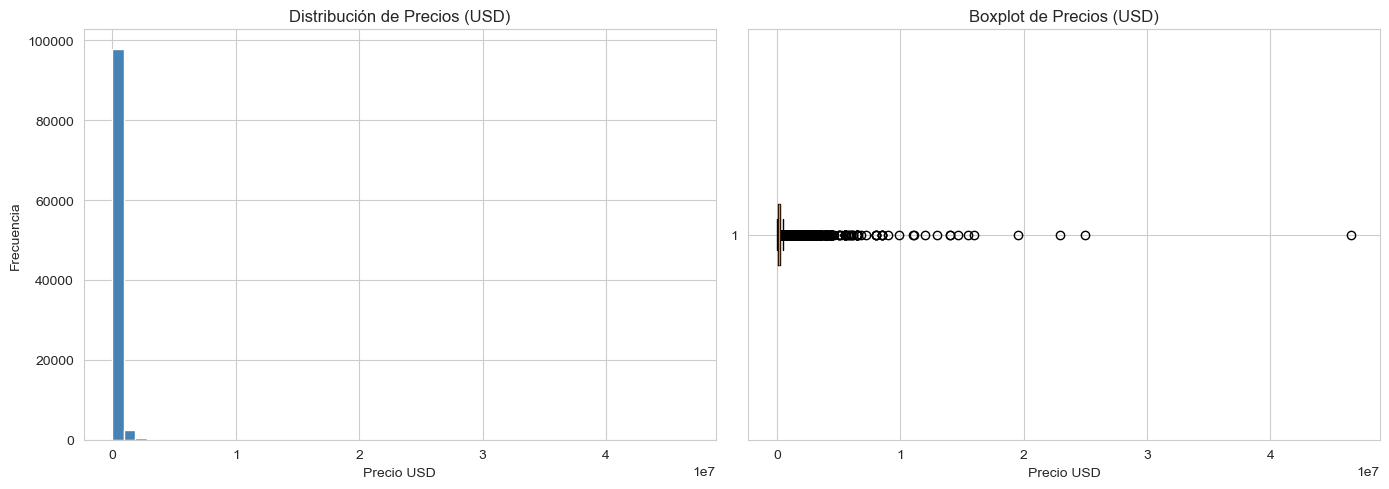

In [7]:
# Visualización de distribución de precios en USD
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['price_aprox_usd'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Precios (USD)')
axes[0].set_xlabel('Precio USD')
axes[0].set_ylabel('Frecuencia')

# Boxplot
axes[1].boxplot(df['price_aprox_usd'], vert=False)
axes[1].set_title('Boxplot de Precios (USD)')
axes[1].set_xlabel('Precio USD')

plt.tight_layout()
plt.show()

In [8]:
# Eliminar outliers de precio usando método IQR
Q1 = df['price_aprox_usd'].quantile(0.25)
Q3 = df['price_aprox_usd'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Límite inferior: USD {limite_inferior:,.0f}")
print(f"Límite superior: USD {limite_superior:,.0f}")

df = df[(df['price_aprox_usd'] >= limite_inferior) & 
        (df['price_aprox_usd'] <= limite_superior)]

print(f"\nFilas después de eliminar outliers: {df.shape[0]}")

Límite inferior: USD -173,165
Límite superior: USD 527,899

Filas después de eliminar outliers: 92445


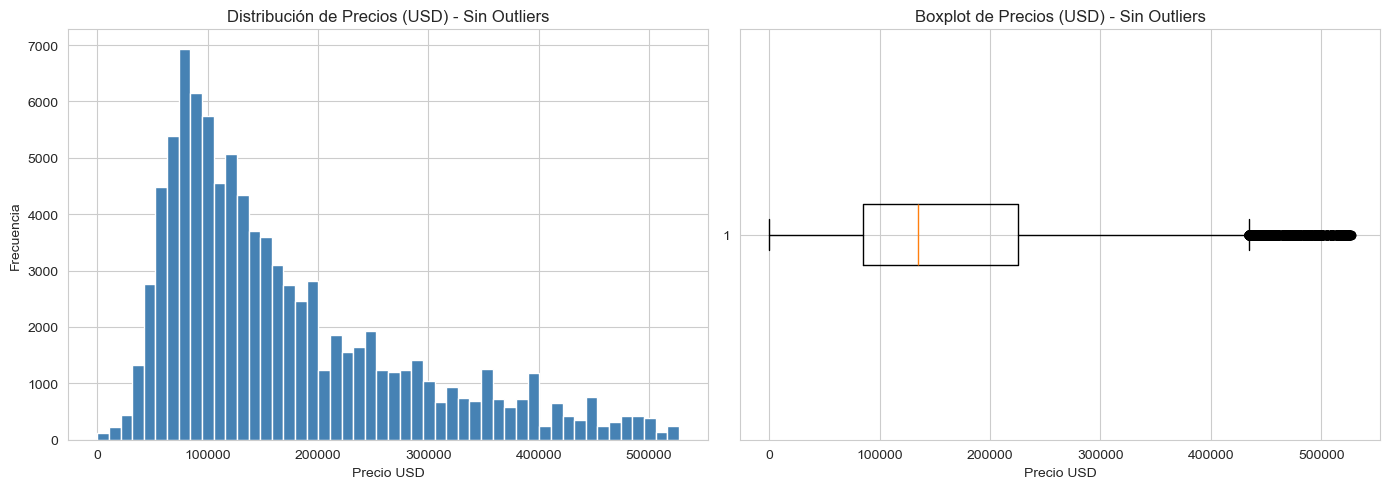

In [9]:
# Distribución de precios después de eliminar outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['price_aprox_usd'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Precios (USD) - Sin Outliers')
axes[0].set_xlabel('Precio USD')
axes[0].set_ylabel('Frecuencia')

# Boxplot
axes[1].boxplot(df['price_aprox_usd'], vert=False)
axes[1].set_title('Boxplot de Precios (USD) - Sin Outliers')
axes[1].set_xlabel('Precio USD')

plt.tight_layout()
plt.show()

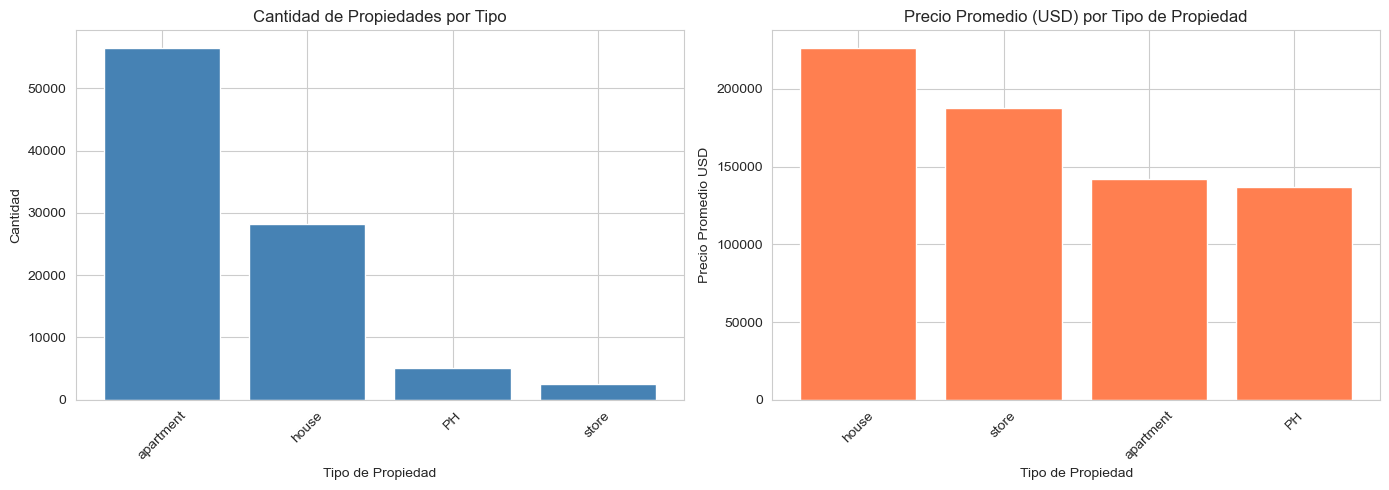

In [10]:
# Distribución por tipo de propiedad
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo por tipo
conteo = df['property_type'].value_counts()
axes[0].bar(conteo.index, conteo.values, color='steelblue', edgecolor='white')
axes[0].set_title('Cantidad de Propiedades por Tipo')
axes[0].set_xlabel('Tipo de Propiedad')
axes[0].set_ylabel('Cantidad')
axes[0].tick_params(axis='x', rotation=45)

# Precio promedio por tipo
precio_tipo = df.groupby('property_type')['price_aprox_usd'].mean().sort_values(ascending=False)
axes[1].bar(precio_tipo.index, precio_tipo.values, color='coral', edgecolor='white')
axes[1].set_title('Precio Promedio (USD) por Tipo de Propiedad')
axes[1].set_xlabel('Tipo de Propiedad')
axes[1].set_ylabel('Precio Promedio USD')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

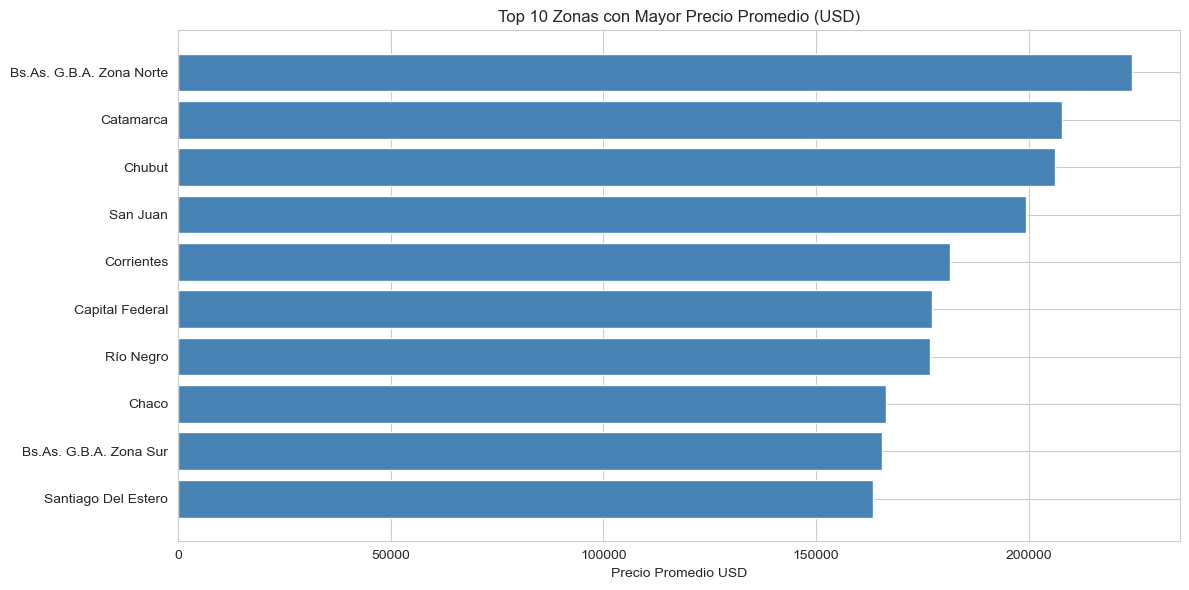

In [11]:
# Top 10 provincias/estados con mayor precio promedio
precio_zona = df.groupby('state_name')['price_aprox_usd'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(precio_zona.index, precio_zona.values, color='steelblue', edgecolor='white')
plt.title('Top 10 Zonas con Mayor Precio Promedio (USD)')
plt.xlabel('Precio Promedio USD')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

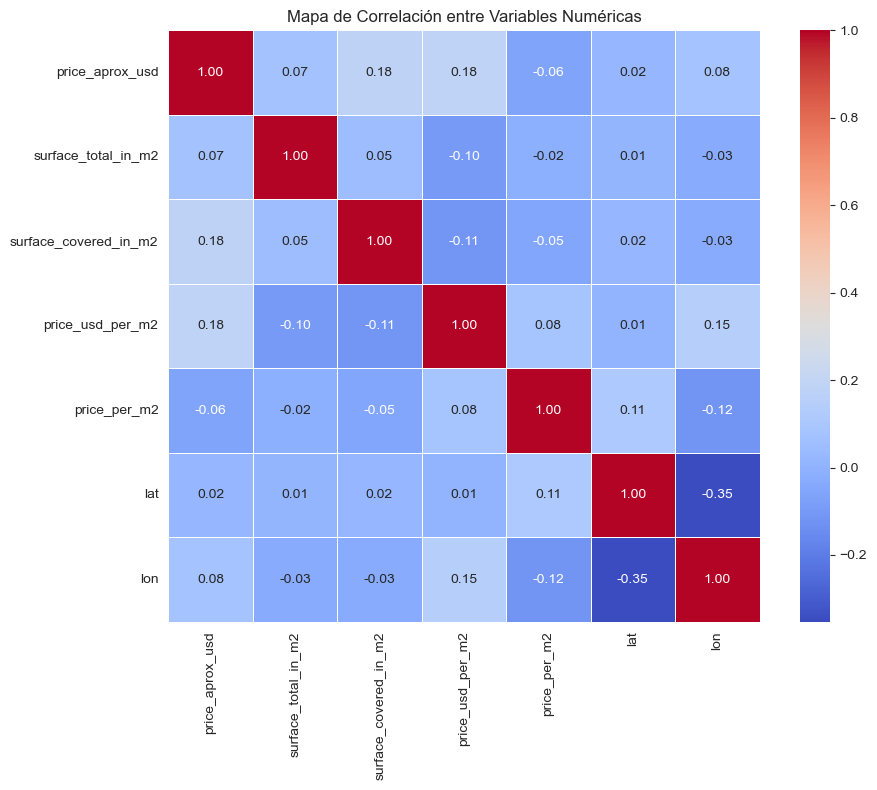

In [12]:
# Mapa de correlación entre variables numéricas
plt.figure(figsize=(10, 8))
correlacion = df[['price_aprox_usd', 'surface_total_in_m2', 
                   'surface_covered_in_m2', 'price_usd_per_m2', 
                   'price_per_m2', 'lat', 'lon']].corr()

sns.heatmap(correlacion, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, square=True)
plt.title('Mapa de Correlación entre Variables Numéricas')
plt.tight_layout()
plt.show()

In [13]:
# Guardar dataset limpio
df.to_csv('properatti_limpio.csv', index=False)
print("Dataset guardado correctamente ✓")

Dataset guardado correctamente ✓
